In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('RTA Dataset.csv')

In [ ]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [ ]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,521
Vehicle_driver_relation,377
Driving_experience,598
Type_of_vehicle,715
Owner_of_vehicle,351
Service_year_of_vehicle,2957


In [ ]:
df['Hour_1_to_24'] = pd.to_datetime(df['Time']).dt.hour

/tmp/ipykernel_1738/3650465702.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour_1_to_24'] = pd.to_datetime(df['Time']).dt.hour


In [ ]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_1_to_24
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,17
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,1


/tmp/ipykernel_1738/1504989071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Day_of_week', y='Hour_1_to_24', order=gun_sirasi, palette='coolwarm')


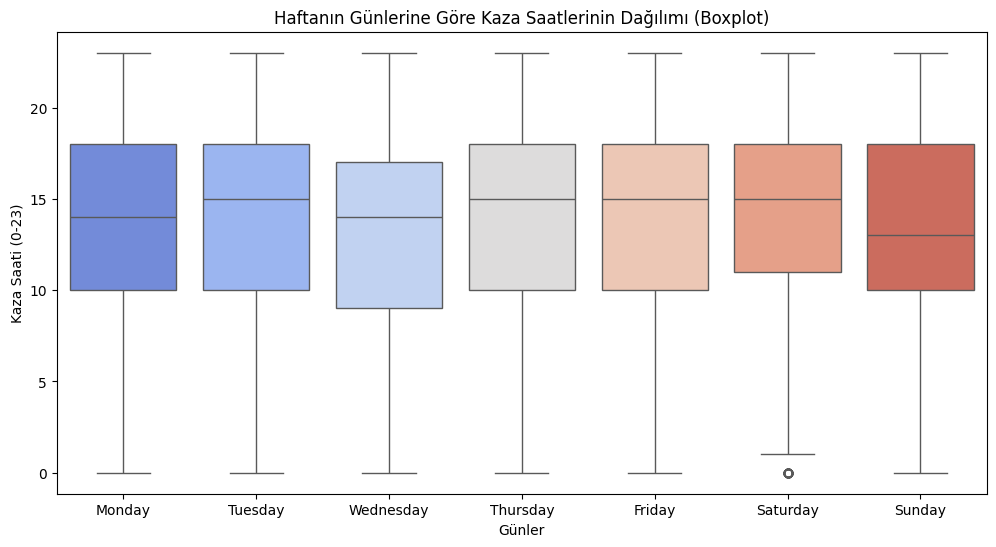

In [ ]:
plt.figure(figsize=(12, 6))

gun_sirasi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.boxplot(data=df, x='Day_of_week', y='Hour_1_to_24', order=gun_sirasi, palette='coolwarm')

plt.title('Haftanın Günlerine Göre Kaza Saatlerinin Dağılımı (Boxplot)')
plt.xlabel('Günler')
plt.ylabel('Kaza Saati (0-23)')
plt.show()

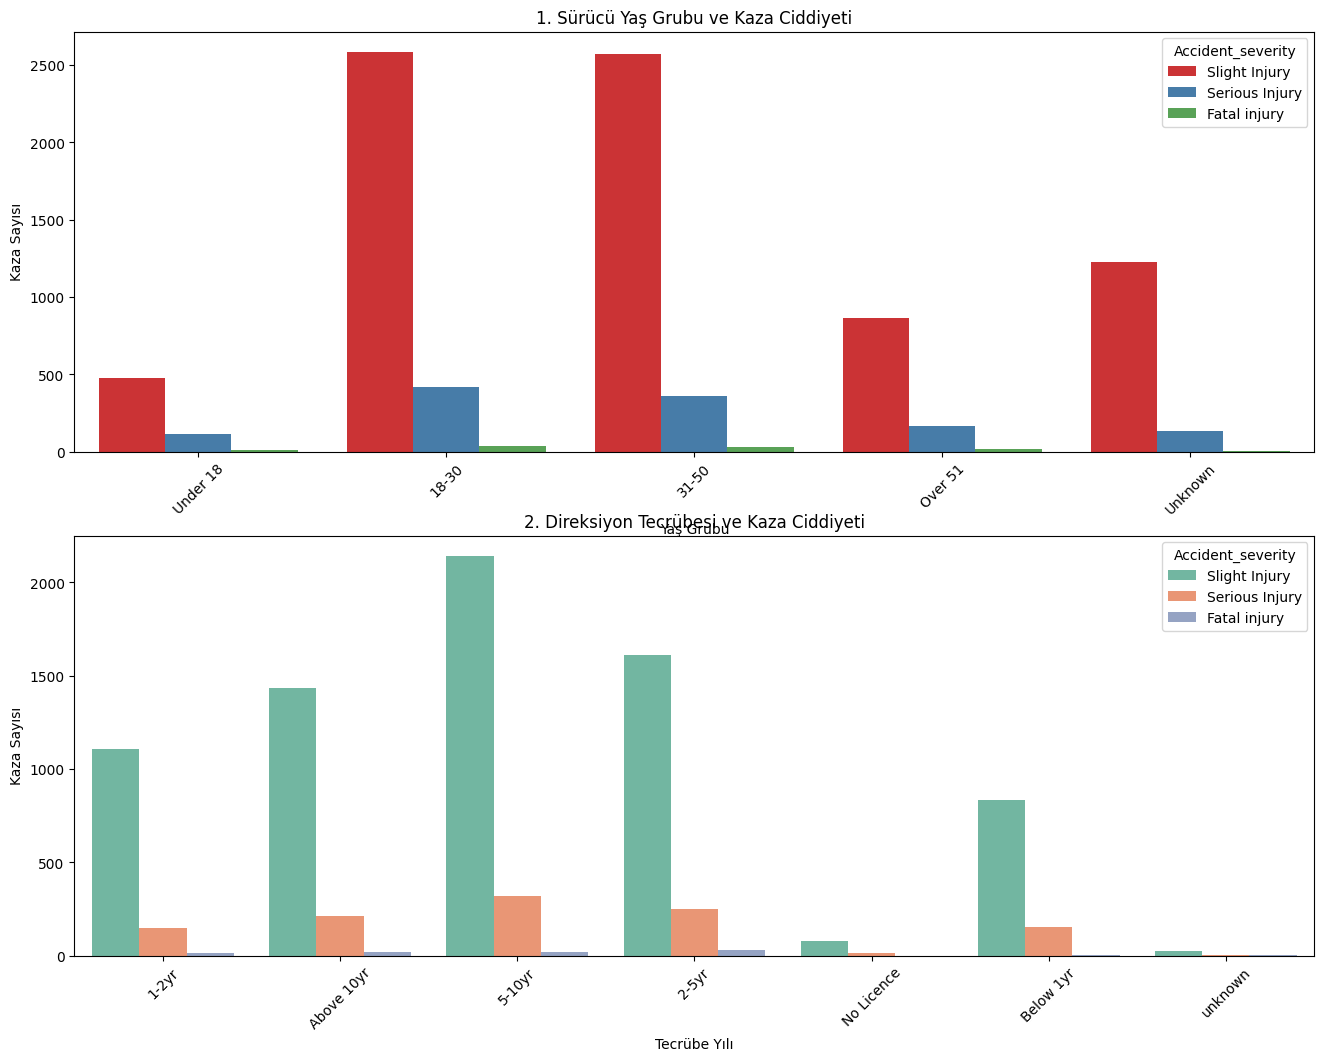

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(16, 12))

yas_sirasi = ['Under 18', '18-30', '31-50', 'Over 51', 'Unknown']
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity', ax=axes[0], order=yas_sirasi, palette='Set1')
axes[0].set_title('1. Sürücü Yaş Grubu ve Kaza Ciddiyeti')
axes[0].set_xlabel('Yaş Grubu')
axes[0].set_ylabel('Kaza Sayısı')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Driving_experience', hue='Accident_severity', ax=axes[1], palette='Set2')
axes[1].set_title('2. Direksiyon Tecrübesi ve Kaza Ciddiyeti')
axes[1].set_xlabel('Tecrübe Yılı')
axes[1].set_ylabel('Kaza Sayısı')
axes[1].tick_params(axis='x', rotation=45)


In [ ]:
unknown_yas_sayisi= (df['Age_band_of_driver']=='Unknown').sum()
print(unknown_yas_sayisi)


1365


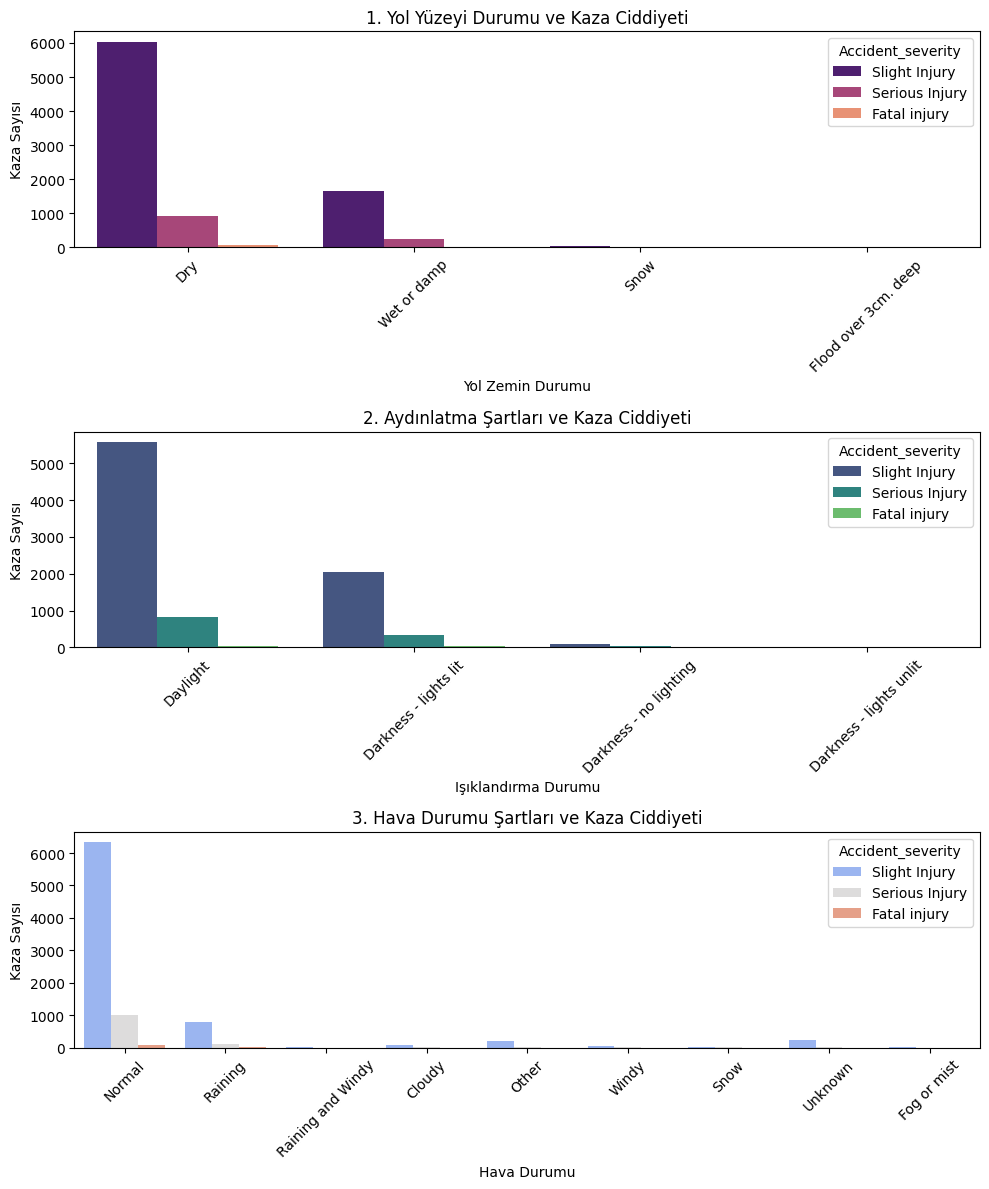

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,12))

sns.countplot(data=df, x='Road_surface_conditions', hue='Accident_severity', ax=axes[0], palette='magma')
axes[0].set_title('1. Yol Yüzeyi Durumu ve Kaza Ciddiyeti')
axes[0].set_xlabel('Yol Zemin Durumu')
axes[0].set_ylabel('Kaza Sayısı')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Light_conditions', hue='Accident_severity', ax=axes[1], palette='viridis')
axes[1].set_title('2. Aydınlatma Şartları ve Kaza Ciddiyeti')
axes[1].set_xlabel('Işıklandırma Durumu')
axes[1].set_ylabel('Kaza Sayısı')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Weather_conditions', hue='Accident_severity', ax=axes[2], palette='coolwarm')
axes[2].set_title('3. Hava Durumu Şartları ve Kaza Ciddiyeti')
axes[2].set_xlabel('Hava Durumu')
axes[2].set_ylabel('Kaza Sayısı')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1738/3944892216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neden_yarali, x='Number_of_casualties', y='Cause_of_accident', palette='Reds_r')


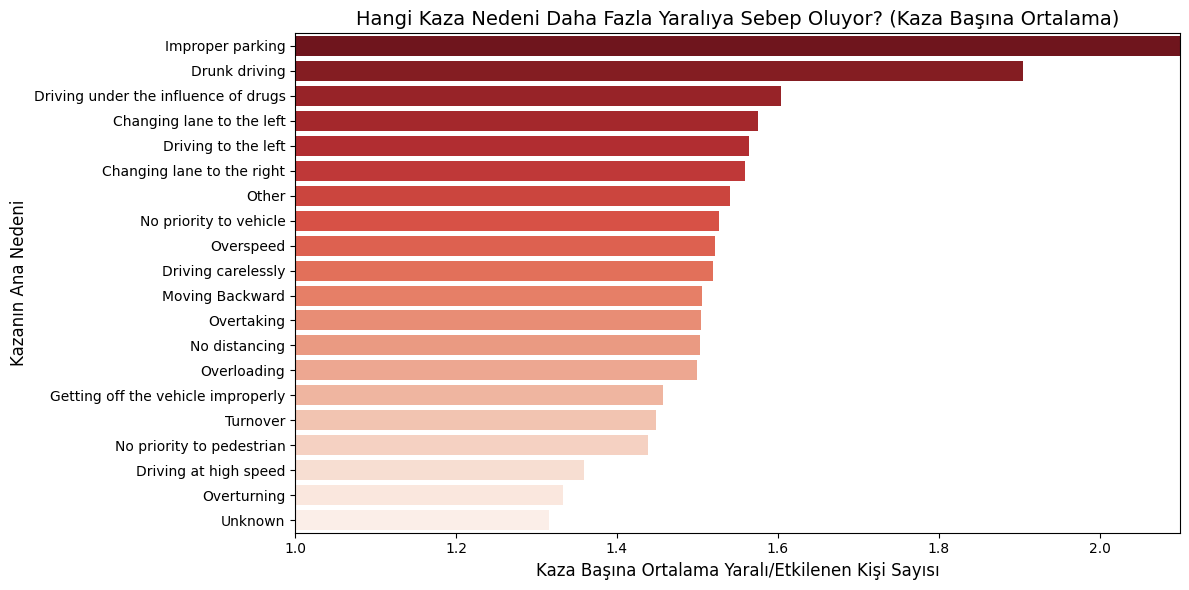

In [ ]:
neden_yarali = df.groupby('Cause_of_accident')['Number_of_casualties'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=neden_yarali, x='Number_of_casualties', y='Cause_of_accident', palette='Reds_r')

plt.title('Hangi Kaza Nedeni Daha Fazla Yaralıya Sebep Oluyor? (Kaza Başına Ortalama)', fontsize=14)
plt.xlabel('Kaza Başına Ortalama Yaralı/Etkilenen Kişi Sayısı', fontsize=12)
plt.ylabel('Kazanın Ana Nedeni', fontsize=12)

plt.xlim(1.0, 2.1)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

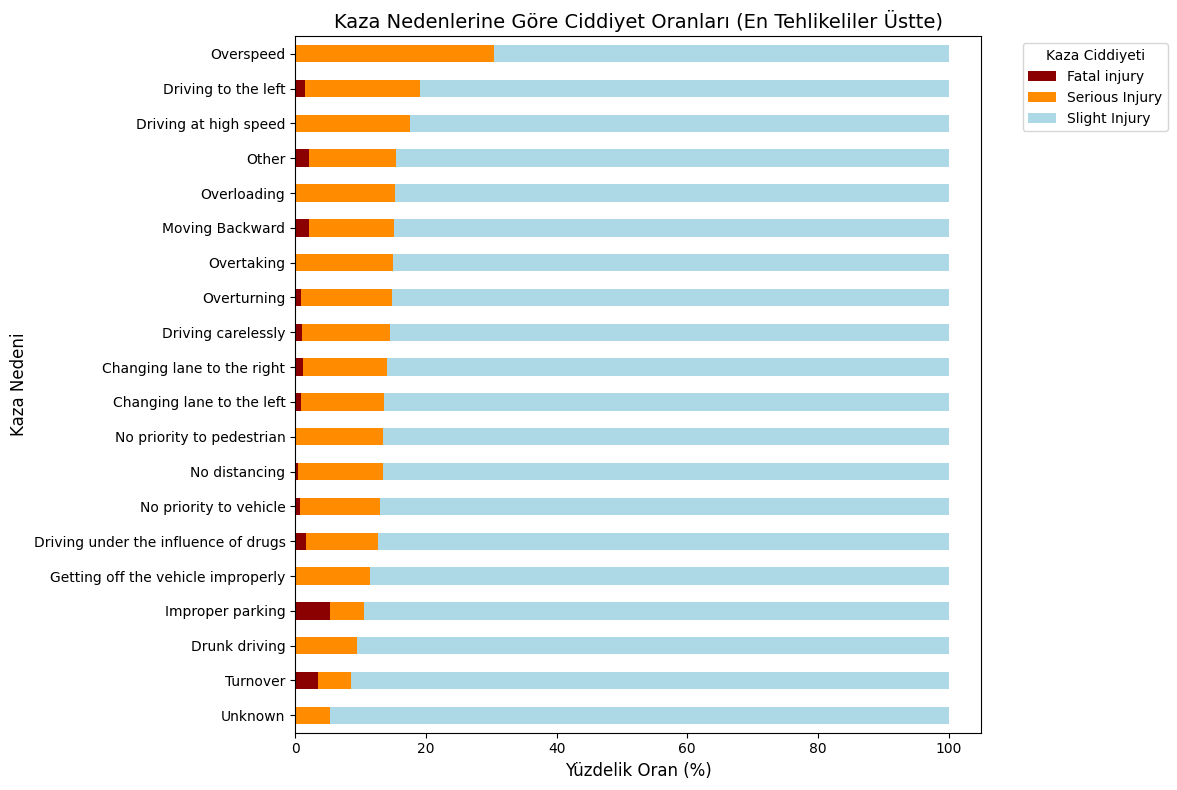

In [ ]:
neden_ciddiyet= pd.crosstab(df['Cause_of_accident'], df['Accident_severity'], normalize='index') * 100

tehlike_orani = neden_ciddiyet['Fatal injury'] + neden_ciddiyet['Serious Injury']
neden_ciddiyet_sirali = neden_ciddiyet.loc[tehlike_orani.sort_values(ascending=True).index]

renk_ayari = ['darkred', 'darkorange', 'lightblue']
kolon_sirasi = ['Fatal injury', 'Serious Injury', 'Slight Injury']
neden_ciddiyet_sirali = neden_ciddiyet_sirali[kolon_sirasi]

plt.figure(figsize=(12, 10))
neden_ciddiyet_sirali.plot(kind='barh', stacked=True, color=renk_ayari, figsize=(12, 8))

plt.title('Kaza Nedenlerine Göre Ciddiyet Oranları (En Tehlikeliler Üstte)', fontsize=14)
plt.xlabel('Yüzdelik Oran (%)', fontsize=12)
plt.ylabel('Kaza Nedeni', fontsize=12)

plt.legend(title='Kaza Ciddiyeti', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

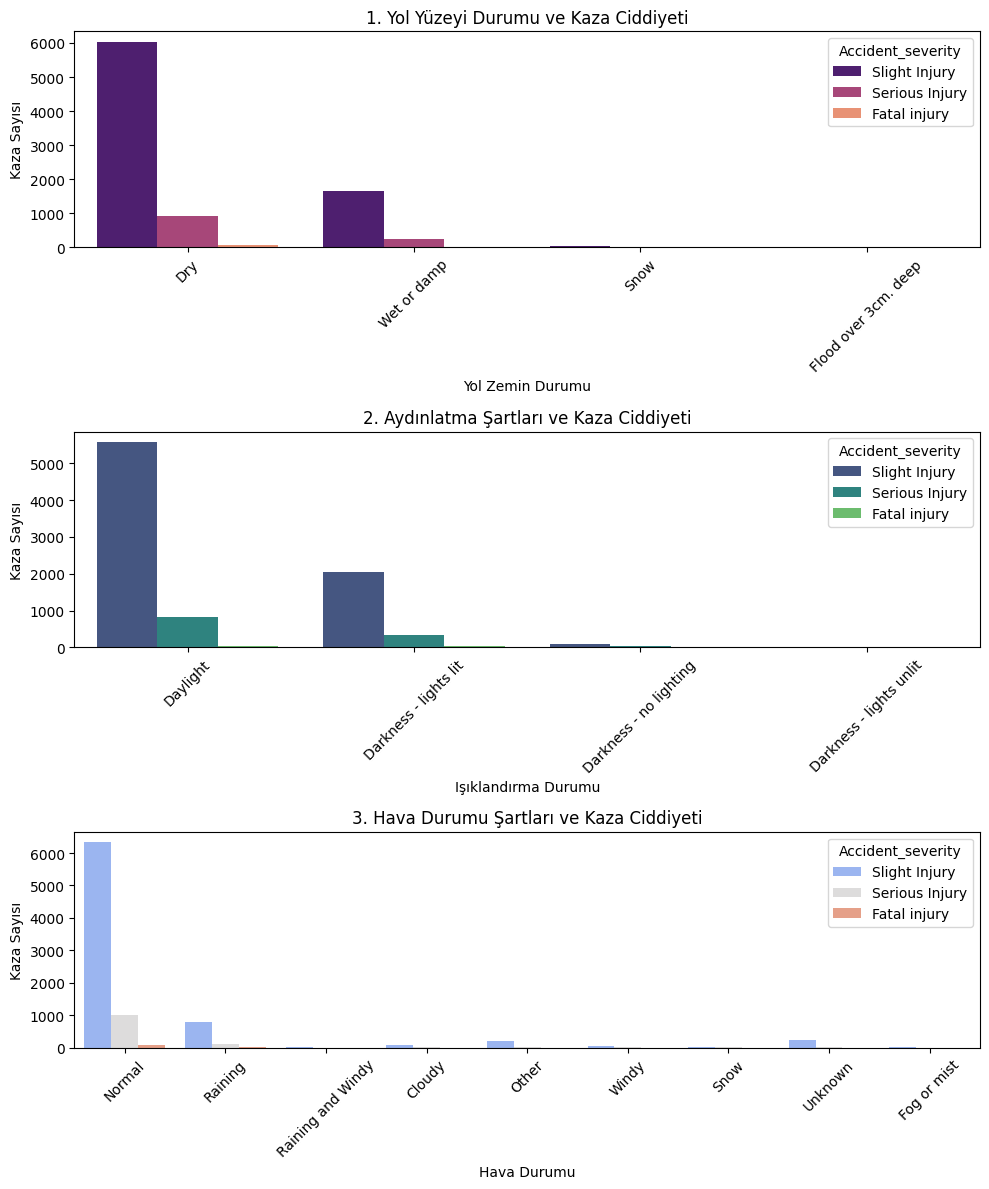

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,12))

sns.countplot(data=df, x='Road_surface_conditions', hue='Accident_severity', ax=axes[0], palette='magma')
axes[0].set_title('1. Yol Yüzeyi Durumu ve Kaza Ciddiyeti')
axes[0].set_xlabel('Yol Zemin Durumu')
axes[0].set_ylabel('Kaza Sayısı')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Light_conditions', hue='Accident_severity', ax=axes[1], palette='viridis')
axes[1].set_title('2. Aydınlatma Şartları ve Kaza Ciddiyeti')
axes[1].set_xlabel('Işıklandırma Durumu')
axes[1].set_ylabel('Kaza Sayısı')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Weather_conditions', hue='Accident_severity', ax=axes[2], palette='coolwarm')
axes[2].set_title('3. Hava Durumu Şartları ve Kaza Ciddiyeti')
axes[2].set_xlabel('Hava Durumu')
axes[2].set_ylabel('Kaza Sayısı')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.drop(['Educational_level','Time','Work_of_casuality','Service_year_of_vehicle', 'Defect_of_vehicle'], axis=1)



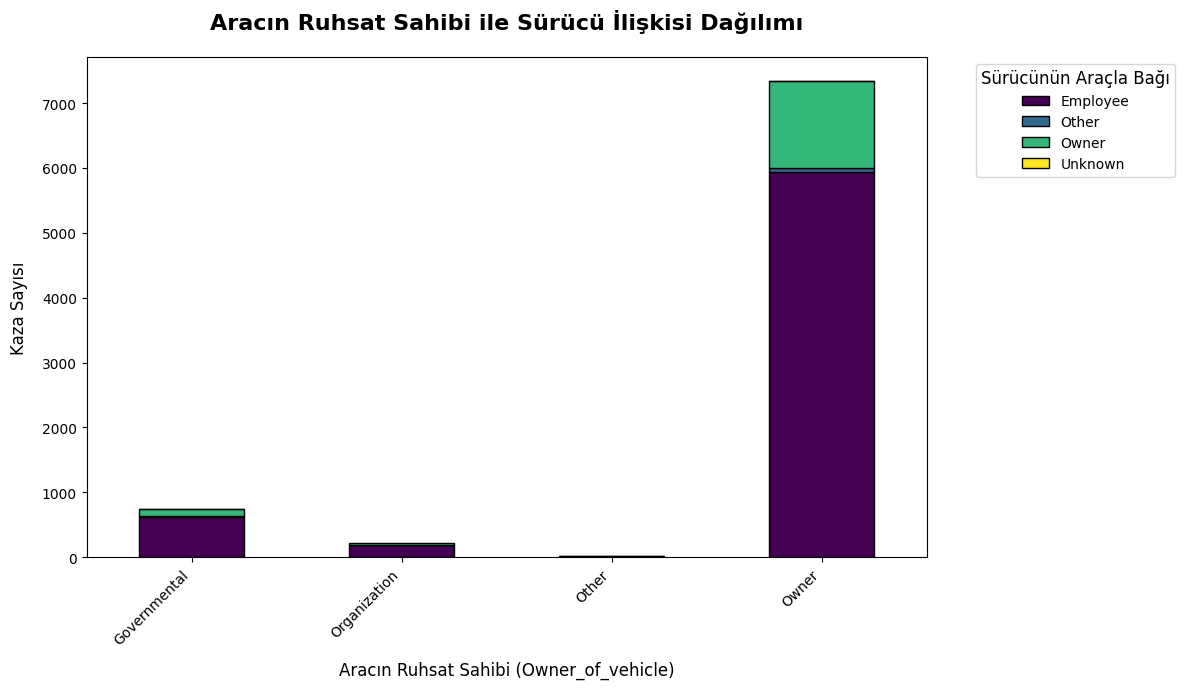

In [ ]:

# İki sütunun birbiriyle olan kesişim sayısını hesaplayan bir tablo (Crosstab) oluşturuyoruz
iliski_tablosu = pd.crosstab(df_clean['Owner_of_vehicle'], df_clean['Vehicle_driver_relation'])

# Yığılmış Sütun Grafiğimizi çizdiriyoruz
ax = iliski_tablosu.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='black')

# Grafiğin süslemeleri (Başlık, Eksen İsimleri vb.)
plt.title('Aracın Ruhsat Sahibi ile Sürücü İlişkisi Dağılımı', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Aracın Ruhsat Sahibi (Owner_of_vehicle)', fontsize=12, labelpad=10)
plt.ylabel('Kaza Sayısı', fontsize=12, labelpad=10)

# X eksenindeki yazıları daha okunaklı olması için hafif eğik yazdırıyoruz
plt.xticks(rotation=45, ha='right')

# Lejantı (Renklerin ne anlama geldiğini gösteren kutu) dışarıya, düzenli bir şekilde koyuyoruz
plt.legend(title='Sürücünün Araçla Bağı', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

# Grafiğin ekrana tam sığması için daraltıyoruz
plt.tight_layout()

# Ve grafiği gösteriyoruz!
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         8998 non-null   object 
 1   Day_of_week                  8998 non-null   object 
 2   Age_band_of_driver           8998 non-null   object 
 3   Sex_of_driver                8998 non-null   object 
 4   Educational_level            8477 non-null   object 
 5   Vehicle_driver_relation      8621 non-null   object 
 6   Driving_experience           8400 non-null   object 
 7   Type_of_vehicle              8283 non-null   object 
 8   Owner_of_vehicle             8647 non-null   object 
 9   Service_year_of_vehicle      6041 non-null   object 
 10  Defect_of_vehicle            5710 non-null   object 
 11  Area_accident_occured        8822 non-null   object 
 12  Lanes_or_Medians             8702 non-null   object 
 13  Road_allignment   

In [ ]:
df['Service_year_of_vehicle'].unique()

array(['Above 10yr', '5-10yrs', nan, '1-2yr', '2-5yrs', 'Unknown',
       'Below 1yr'], dtype=object)

In [ ]:
df_clean.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_1_to_24
0,Monday,18-30,Male,Employee,1-2yr,Automobile,Owner,Residential areas,NaN,Tangent road with flat terrain,...,Going straight,na,na,na,na,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,Undivided Two way,Tangent road with flat terrain,...,Going straight,na,na,na,na,NaN,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Employee,1-2yr,Lorry (41?100Q),Owner,Recreational areas,other,NaN,...,Going straight,Driver or rider,Male,31-50,3,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,other,Tangent road with mild grade and flat terrain,...,Going straight,Pedestrian,Female,18-30,3,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Employee,2-5yr,NaN,Owner,Industrial areas,other,Tangent road with flat terrain,...,Going straight,na,na,na,na,NaN,Not a Pedestrian,Overtaking,Slight Injury,1


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Day_of_week                  8998 non-null   object 
 1   Age_band_of_driver           8998 non-null   object 
 2   Sex_of_driver                8998 non-null   object 
 3   Vehicle_driver_relation      8621 non-null   object 
 4   Driving_experience           8400 non-null   object 
 5   Type_of_vehicle              8283 non-null   object 
 6   Owner_of_vehicle             8647 non-null   object 
 7   Area_accident_occured        8822 non-null   object 
 8   Lanes_or_Medians             8702 non-null   object 
 9   Road_allignment              8884 non-null   object 
 10  Types_of_Junction            8997 non-null   object 
 11  Road_surface_type            8871 non-null   object 
 12  Road_surface_conditions      8997 non-null   object 
 13  Light_conditions  

In [ ]:
df_clean['Fitness_of_casuality'].unique()

array([nan, 'Normal', 'Deaf', 'Other', 'Blind', 'NormalNormal'],
      dtype=object)

In [ ]:
df_clean['Fitness_of_casuality'].fillna('Normal', inplace=True)

df_clean['Fitness_of_casuality'] = df_clean['Fitness_of_casuality'].replace('NormalNormal', 'Normal')

/tmp/ipykernel_1738/1208043196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Fitness_of_casuality'].fillna('Normal', inplace=True)


In [ ]:
df_clean['Fitness_of_casuality'].unique()

array(['Normal', 'Deaf', 'Other', 'Blind'], dtype=object)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Day_of_week                  8998 non-null   object 
 1   Age_band_of_driver           8998 non-null   object 
 2   Sex_of_driver                8998 non-null   object 
 3   Vehicle_driver_relation      8621 non-null   object 
 4   Driving_experience           8400 non-null   object 
 5   Type_of_vehicle              8283 non-null   object 
 6   Owner_of_vehicle             8647 non-null   object 
 7   Area_accident_occured        8822 non-null   object 
 8   Lanes_or_Medians             8702 non-null   object 
 9   Road_allignment              8884 non-null   object 
 10  Types_of_Junction            8997 non-null   object 
 11  Road_surface_type            8871 non-null   object 
 12  Road_surface_conditions      8997 non-null   object 
 13  Light_conditions  

In [ ]:
# Boş (NaN) değerleri 'Unknown' (Bilinmeyen) olarak dolduruyoruz
df_clean['Vehicle_driver_relation'].fillna('Unknown', inplace=True)

print("Vehicle_driver_relation sütunundaki eksikler 'Unknown' ile dolduruldu!")

Vehicle_driver_relation sütunundaki eksikler 'Unknown' ile dolduruldu!


/tmp/ipykernel_1738/710265172.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Vehicle_driver_relation'].fillna('Unknown', inplace=True)


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Day_of_week                  8998 non-null   object 
 1   Age_band_of_driver           8998 non-null   object 
 2   Sex_of_driver                8998 non-null   object 
 3   Vehicle_driver_relation      8998 non-null   object 
 4   Driving_experience           8400 non-null   object 
 5   Type_of_vehicle              8283 non-null   object 
 6   Owner_of_vehicle             8647 non-null   object 
 7   Area_accident_occured        8822 non-null   object 
 8   Lanes_or_Medians             8702 non-null   object 
 9   Road_allignment              8884 non-null   object 
 10  Types_of_Junction            8997 non-null   object 
 11  Road_surface_type            8871 non-null   object 
 12  Road_surface_conditions      8997 non-null   object 
 13  Light_conditions  

In [ ]:
# Boş (NaN) değerleri 'Unknown' (Bilinmeyen) olarak dolduruyoruz
df_clean['Vehicle_driver_relation'].fillna('Unknown', inplace=True)

print("Vehicle_driver_relation sütunundaki eksikler 'Unknown' ile dolduruldu!")

Vehicle_driver_relation sütunundaki eksikler 'Unknown' ile dolduruldu!


In [ ]:
df_clean['Type_of_vehicle'].unique()

array(['Automobile', 'Public (> 45 seats)', 'Lorry (41?100Q)', nan,
       'Public (13?45 seats)', 'Lorry (11?40Q)', 'Long lorry',
       'Public (12 seats)', 'Taxi', 'Pick up upto 10Q', 'Stationwagen',
       'Ridden horse', 'Other', 'Bajaj', 'Turbo', 'Motorcycle',
       'Special vehicle', 'Bicycle'], dtype=object)

In [ ]:
# Type_of_vehicle sütunundaki boşlukları mevcut 'Other' kategorisiyle birleştiriyoruz
# Not: Verindeki kelime tam olarak nasıl yazıldıysa (Örn: 'other' veya 'Other') onu kullanmalısın
df_clean['Type_of_vehicle'].fillna('Other', inplace=True)

print("İşlem tamam! Eksikler başarıyla 'Other' grubuna dahil edildi.")

İşlem tamam! Eksikler başarıyla 'Other' grubuna dahil edildi.


/tmp/ipykernel_1738/3381646742.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Type_of_vehicle'].fillna('Other', inplace=True)


In [ ]:
df_clean['Owner_of_vehicle'].unique()

array(['Owner', 'Governmental', nan, 'Organization', 'Other'],
      dtype=object)

In [ ]:
df_clean['Owner_of_vehicle'].fillna('Other', inplace=True)

print("İşlem tamam! Eksikler başarıyla 'Other' grubuna dahil edildi.")

İşlem tamam! Eksikler başarıyla 'Other' grubuna dahil edildi.


/tmp/ipykernel_1738/3667214831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Owner_of_vehicle'].fillna('Other', inplace=True)


In [ ]:
eksik_veriler = df_clean.isnull().sum()

eksik_olanlar = eksik_veriler[eksik_veriler > 0]

if len(eksik_olanlar) == 0:
    print("🎉 Harika haber! Veri setinde tek bir eksik (Null/NaN) değer bile kalmamış. Verin jilet gibi!")
else:
    print("⚠️ Dikkat! Hala eksik veri içeren sütunlar şunlar (Büyükten küçüğe):")
    # Eksik sayılarını büyükten küçüğe sıralayıp gösteriyoruz
    print(eksik_olanlar.sort_values(ascending=False))

⚠️ Dikkat! Hala eksik veri içeren sütunlar şunlar (Büyükten küçüğe):
Driving_experience             598
Lanes_or_Medians               296
Vehicle_movement               211
Area_accident_occured          176
Road_surface_type              127
Road_allignment                114
Type_of_collision              106
Road_surface_conditions          1
Light_conditions                 1
Weather_conditions               1
Number_of_vehicles_involved      1
Types_of_Junction                1
Number_of_casualties             1
Casualty_class                   1
Sex_of_casualty                  1
Age_band_of_casualty             1
Casualty_severity                1
Pedestrian_movement              1
Cause_of_accident                1
Accident_severity                1
dtype: int64


In [ ]:
df_clean['Types_of_Junction'].unique()

array(['No junction', 'Y Shape', 'Crossing', 'O Shape', 'Other',
       'Unknown', 'T Shape', 'X Shape', nan], dtype=object)

In [ ]:
# Yeni ve modern yöntemle (Pandas 3.0 uyumlu) boşlukları 'Unknown' yapıyoruz
df_clean['Types_of_Junction'] = df_clean['Types_of_Junction'].fillna('Unknown')


In [ ]:
df_clean['Driving_experience'].unique()

array(['1-2yr', 'Above 10yr', '5-10yr', '2-5yr', nan, 'No Licence',
       'Below 1yr', 'unknown'], dtype=object)

In [ ]:
df_clean['Driving_experience'].fillna('Unknown', inplace=True)

/tmp/ipykernel_1738/1257949992.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Driving_experience'].fillna('Unknown', inplace=True)


In [ ]:
df_clean['Lanes_or_Medians'].unique()

array([nan, 'Undivided Two way', 'other', 'Double carriageway (median)',
       'One way', 'Two-way (divided with solid lines road marking)',
       'Two-way (divided with broken lines road marking)', 'Unknown'],
      dtype=object)

In [ ]:

df_clean['Lanes_or_Medians'] = df_clean['Lanes_or_Medians'].fillna('Unknown')

In [ ]:
df_clean['Vehicle_driver_relation']=df_clean['Vehicle_driver_relation'].fillna('Unknown')

In [ ]:
df_clean['Vehicle_movement'].unique()

array(['Going straight', 'U-Turn', 'Moving Backward', 'Turnover',
       'Waiting to go', 'Getting off', 'Reversing', 'Unknown', 'Parked',
       'Stopping', 'Overtaking', 'Other', 'Entering a junction', nan],
      dtype=object)

In [ ]:
df_clean['Vehicle_movement']=df_clean['Vehicle_movement'].fillna('Unknown')

In [ ]:
df_clean['Area_accident_occured'].unique()

array(['Residential areas', 'Office areas', '  Recreational areas',
       ' Industrial areas', nan, 'Other', ' Church areas',
       '  Market areas', 'Unknown', 'Rural village areas',
       ' Outside rural areas', ' Hospital areas', 'School areas',
       'Rural village areasOffice areas', 'Recreational areas'],
      dtype=object)

In [ ]:
df_clean["Area_accident_occured"]=df_clean["Area_accident_occured"].fillna('Unknown')

In [ ]:
df_clean['Road_surface_type'].unique()

array(['Asphalt roads', 'Earth roads', nan,
       'Asphalt roads with some distress', 'Gravel roads', 'Other'],
      dtype=object)

In [ ]:
df_clean['Road_surface_type']=df_clean['Road_surface_type'].fillna('Other')

In [ ]:
df_clean['Type_of_collision'].unique()

array(['Collision with roadside-parked vehicles',
       'Vehicle with vehicle collision',
       'Collision with roadside objects', 'Collision with animals',
       'Other', 'Rollover', 'Fall from vehicles',
       'Collision with pedestrians', 'With Train', 'Unknown', nan],
      dtype=object)

In [ ]:
df_clean['Type_of_collision']=df_clean['Type_of_collision'].fillna('Unknown')

In [ ]:
df_clean['Road_allignment'].unique()

array(['Tangent road with flat terrain', nan,
       'Tangent road with mild grade and flat terrain', 'Escarpments',
       'Tangent road with rolling terrain', 'Gentle horizontal curve',
       'Tangent road with mountainous terrain and',
       'Steep grade downward with mountainous terrain',
       'Sharp reverse curve',
       'Steep grade upward with mountainous terrain'], dtype=object)

In [ ]:
# Yeni ve modern yöntemle (Pandas 3.0 uyumlu) boşlukları 'Unknown' yapıyoruz
df_clean['Road_allignment'] = df_clean['Road_allignment'].fillna('Unknown')


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Day_of_week                  8998 non-null   object 
 1   Age_band_of_driver           8998 non-null   object 
 2   Sex_of_driver                8998 non-null   object 
 3   Vehicle_driver_relation      8998 non-null   object 
 4   Driving_experience           8998 non-null   object 
 5   Type_of_vehicle              8998 non-null   object 
 6   Owner_of_vehicle             8998 non-null   object 
 7   Area_accident_occured        8998 non-null   object 
 8   Lanes_or_Medians             8998 non-null   object 
 9   Road_allignment              8998 non-null   object 
 10  Types_of_Junction            8998 non-null   object 
 11  Road_surface_type            8998 non-null   object 
 12  Road_surface_conditions      8997 non-null   object 
 13  Light_conditions  

In [ ]:
# Sadece metin (object) veri tipine sahip sütunları filtreleyip alıyoruz
metin_sutunlari = df_clean.select_dtypes(include=['object']).columns
print(metin_sutunlari)

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle',
       'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident',
       'Accident_severity'],
      dtype='object')


In [ ]:
df_clean.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_1_to_24
0,Monday,18-30,Male,Employee,1-2yr,Automobile,Owner,Residential areas,Unknown,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,Undivided Two way,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Employee,1-2yr,Lorry (41?100Q),Owner,Recreational areas,other,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,other,Tangent road with mild grade and flat terrain,...,Going straight,Pedestrian,Female,18-30,3,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Employee,2-5yr,Other,Owner,Industrial areas,other,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Overtaking,Slight Injury,1


In [ ]:
df_clean['Sex_of_casualty'].unique()

array(['na', 'Male', 'Female', nan], dtype=object)

In [ ]:
# Günlerin mantıksal sırasını belirten bir sözlük (harita) oluşturuyoruz
gun_haritasi = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}

# .map() fonksiyonu ile kelimeleri bu sayılarla değiştiriyoruz
df_clean['Day_of_week'] = df_clean['Day_of_week'].map(gun_haritasi)


In [ ]:
df['Age_band_of_driver'].unique()

array(['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown'], dtype=object)

In [ ]:
yas_haritasi_0_5 = {
    'Unknown': 0,        # Bilinmeyenleri modele nötr/başlangıç noktası olarak 0 veriyoruz
    'Under 18': 1,       # En genç ve muhtemelen en tecrübesiz grup
    '18-30': 2,          # Genç sürücüler
    '31-50': 3,          # Orta yaş / Olgun sürücüler
    '51-60': 4,          # İleri yaş başlangıcı
    'Over 51': 5         # En üst yaş grubu (Verinde 'Over 60' vs. varsa buraya onu yazabilirsin)
}

df_clean['Age_band_of_driver'] = df_clean['Age_band_of_driver'].map(yas_haritasi_0_5)


In [ ]:
cinsiyet_haritasi = {
    'Unkown': 0,       # Erkek
    'Female': 1,     # Kadın
    'Male': 2     # Bilinmeyenler
}

df_clean['Sex_of_driver'] = df_clean['Sex_of_driver'].map(cinsiyet_haritasi)

In [ ]:
df_clean.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_1_to_24
0,1,2,2.0,Employee,1-2yr,Automobile,Owner,Residential areas,Unknown,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Moving Backward,Slight Injury,17
1,1,3,2.0,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,Undivided Two way,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Overtaking,Slight Injury,17
2,1,2,2.0,Employee,1-2yr,Lorry (41?100Q),Owner,Recreational areas,other,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,7,2,2.0,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,other,Tangent road with mild grade and flat terrain,...,Going straight,Pedestrian,Female,18-30,3,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,7,2,2.0,Employee,2-5yr,Other,Owner,Industrial areas,other,Tangent road with flat terrain,...,Going straight,na,na,na,na,Normal,Not a Pedestrian,Overtaking,Slight Injury,1


In [ ]:
df_clean.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle',
       'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident',
       'Accident_severity', 'Hour_1_to_24'],
      dtype='object')

In [ ]:
df_clean.isnull().sum()

,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,171
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Area_accident_occured,0
Lanes_or_Medians,0
Road_allignment,0


In [ ]:
# Modern ve güvenli Pandas yöntemiyle o tehlikeli sütunu tablodan tamamen atıyoruz
df_clean = df_clean.drop('Casualty_severity', axis=1)

print("Harika hamle! Casualty_severity sütunu silindi. Hem 4443 eksik veriden kurtulduk hem de Veri Sızıntısı (Data Leakage) tuzağını bozduk!")

Harika hamle! Casualty_severity sütunu silindi. Hem 4443 eksik veriden kurtulduk hem de Veri Sızıntısı (Data Leakage) tuzağını bozduk!


In [ ]:
df_clean['Sex_of_driver'] = df_clean['Sex_of_driver'].fillna('Unknown')
df_clean['Driving_experience'] = df_clean['Driving_experience'].fillna('unknown') # Veride genelde küçük harfle yazılmıştı
df_clean['Age_band_of_casualty'] = df_clean['Age_band_of_casualty'].fillna('Unknown')

In [ ]:
df_clean.isnull().sum()

,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Area_accident_occured,0
Lanes_or_Medians,0
Road_allignment,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Sadece Label Encoding uygulanacak sırasız (Nominal) sütunların listesi
nominal_sutunlar = [
    'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle',
    'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment',
    'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions',
    'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
    'Casualty_class', 'Sex_of_casualty', 'Fitness_of_casuality',
    'Pedestrian_movement', 'Cause_of_accident'
]

# 2. Kodlayıcımızı çağırıyoruz
le = LabelEncoder()

# 3. Listedeki her bir sütunu döngüye sokup sayısallaştırıyoruz
for sutun in nominal_sutunlar:
    # Eğer sütun verimizde varsa işlemi yap (Hata almamak için güvenlik kontrolü)
    if sutun in df_clean.columns:


        # Sütunu LabelEncoder ile 0, 1, 2... formatına dönüştürüp üzerine yazıyoruz
        df_clean[sutun] = le.fit_transform(df_clean[sutun])

print("Tüm nominal sütunlar LabelEncoder ile başarıyla sayısallaştırıldı!")

# İşlemin sonucunu görmek için veri setinin ilk 5 satırına bakalım:
print(df_clean.head())

Tüm nominal sütunlar LabelEncoder ile başarıyla sayısallaştırıldı!
   Day_of_week  Age_band_of_driver Sex_of_driver  Vehicle_driver_relation  \
0            1                   2           2.0                        0   
1            1                   3           2.0                        0   
2            1                   2           2.0                        0   
3            7                   2           2.0                        0   
4            7                   2           2.0                        0   

  Driving_experience  Type_of_vehicle  Owner_of_vehicle  \
0              1-2yr                0                 3   
1         Above 10yr               11                 3   
2              1-2yr                5                 3   
3             5-10yr               11                 0   
4              2-5yr                7                 3   

   Area_accident_occured  Lanes_or_Medians  Road_allignment  ...  \
0                      9                 5     

In [ ]:
# 1. Sözlüklerimizi (Haritaları) Tanımlıyoruz
kaza_siddeti_haritasi = {'Slight Injury': 0, 'Serious Injury': 1, 'Fatal injury': 2}
gun_haritasi = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
yas_haritasi = {'Unknown': 0, 'na': 0, 'Under 18': 1, '18-30': 2, '31-50': 3, '51-60': 4, 'Over 51': 5}
tecrube_haritasi = {'unknown': 0, 'No Licence': 1, 'Below 1yr': 2, '1-2yr': 3, '2-5yr': 4, '5-10yr': 5, 'Above 10yr': 6}
isik_haritasi = {'Daylight': 1, 'Darkness - lights lit': 2, 'Darkness - lights unlit': 3, 'Darkness - no lighting': 4}
cinsiyet_haritasi = {'Male': 0, 'Female': 1, 'Unknown': 2}

# 2. HEDEF DEĞİŞKENİ (y) KODLAMA
if 'Accident_severity' in df_clean.columns:
    df_clean['Accident_severity'] = df_clean['Accident_severity'].map(kaza_siddeti_haritasi)

# 3. SIRALI (ORDINAL) SÜTUNLARI KODLAMA
ordinal_sutunlar = {
    'Day_of_week': gun_haritasi,
    'Age_band_of_driver': yas_haritasi,
    'Age_band_of_casualty': yas_haritasi,
    'Driving_experience': tecrube_haritasi,
    'Light_conditions': isik_haritasi,
    'Sex_of_driver': cinsiyet_haritasi
}

# 4. Döngü ile haritaları uygulayıp olası boşlukları nötralize ediyoruz
for sutun, harita in ordinal_sutunlar.items():
    if sutun in df_clean.columns:
        # Metinleri sayılara çevir
        df_clean[sutun] = df_clean[sutun].map(harita)

        # Harf farklılığından dolayı eşleşmeyip boş (NaN) kalanları sistem hata vermesin diye 0 yap
        df_clean[sutun] = df_clean[sutun].fillna(0)

print("Tüm manuel (Map) kodlamalar hiyerarşiye uygun olarak başarıyla tamamlandı!")

Tüm manuel (Map) kodlamalar hiyerarşiye uygun olarak başarıyla tamamlandı!


In [ ]:
from sklearn.model_selection import train_test_split

print("✂️ Train-Test Split İşlemi Başlıyor...\n")

# 1. ADIM: Hedef (y) ve İpuçlarını (X) Ayırma
# Hedefimiz: Kazanın şiddeti (Accident_severity)
y = df_clean['Accident_severity']

# İpuçlarımız: Hedef sütunu dışındaki geriye kalan tüm özellikler
X = df_clean.drop('Accident_severity', axis=1)

print("✅ X (İpuçları) ve y (Hedef) başarıyla birbirinden ayrıldı.")

# 2. ADIM: Veriyi %80 Eğitim ve %20 Test Olarak Parçalama
# random_state=42: Kodu her çalıştırdığımızda aynı rastgele ayrımı yapması için bir kilit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n📊 Veri Seti Parçalanma Özeti:")
print(f"-> Modelin antrenman yapacağı veri sayısı (X_train): {X_train.shape[0]} satır")
print(f"-> Modelin sınava gireceği test verisi sayısı (X_test): {X_test.shape[0]} satır")
print(f"-> Toplam İpucu (Özellik) Sayımız: {X_train.shape[1]} adet")

✂️ Train-Test Split İşlemi Başlıyor...

✅ X (İpuçları) ve y (Hedef) başarıyla birbirinden ayrıldı.

📊 Veri Seti Parçalanma Özeti:
-> Modelin antrenman yapacağı veri sayısı (X_train): 7198 satır
-> Modelin sınava gireceği test verisi sayısı (X_test): 1800 satır
-> Toplam İpucu (Özellik) Sayımız: 26 adet


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("🧹 Hedef değişkeni boş olan satırlar temizleniyor...\n")

# 1. HATA ÇÖZÜMÜ: Cevap anahtarı (y) boş olan satırları tablodan atıyoruz
df_clean = df_clean.dropna(subset=['Accident_severity'])

# 2. X ve y'yi güncel ve temizlenmiş tabloya göre TEKRAR ayırıyoruz
y = df_clean['Accident_severity']
X = df_clean.drop('Accident_severity', axis=1)

# 3. Veriyi tekrar %80 Eğitim ve %20 Test olarak parçalıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🌲 Random Forest Modeli Eğitiliyor...\n")

# 4. Modeli kuruyoruz ve eğitiyoruz (Bu sefer sıfır hata ile!)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("✅ Model eğitimi başarıyla tamamlandı!\n")

# 5. Sınav Vakti ve Karne
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🏆 Modelin Genel Doğruluk Oranı (Accuracy): % {accuracy * 100:.2f}\n")
print("📊 Detaylı Karne (Classification Report):")
print(classification_report(y_test, y_pred))

🧹 Hedef değişkeni boş olan satırlar temizleniyor...

🌲 Random Forest Modeli Eğitiliyor...

✅ Model eğitimi başarıyla tamamlandı!

🏆 Modelin Genel Doğruluk Oranı (Accuracy): % 84.50

📊 Detaylı Karne (Classification Report):
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.92      1521
         1.0       0.00      0.00      0.00       262
         2.0       0.00      0.00      0.00        17

    accuracy                           0.84      1800
   macro avg       0.28      0.33      0.31      1800
weighted avg       0.71      0.84      0.77      1800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 Modelin Karar Mekanizması Çözümleniyor...



/tmp/ipykernel_1738/1084032024.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem_Puanı', y='Özellik', data=ozellik_onemi_df.head(15), palette='viridis')
/tmp/ipykernel_1738/1084032024.py:27: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


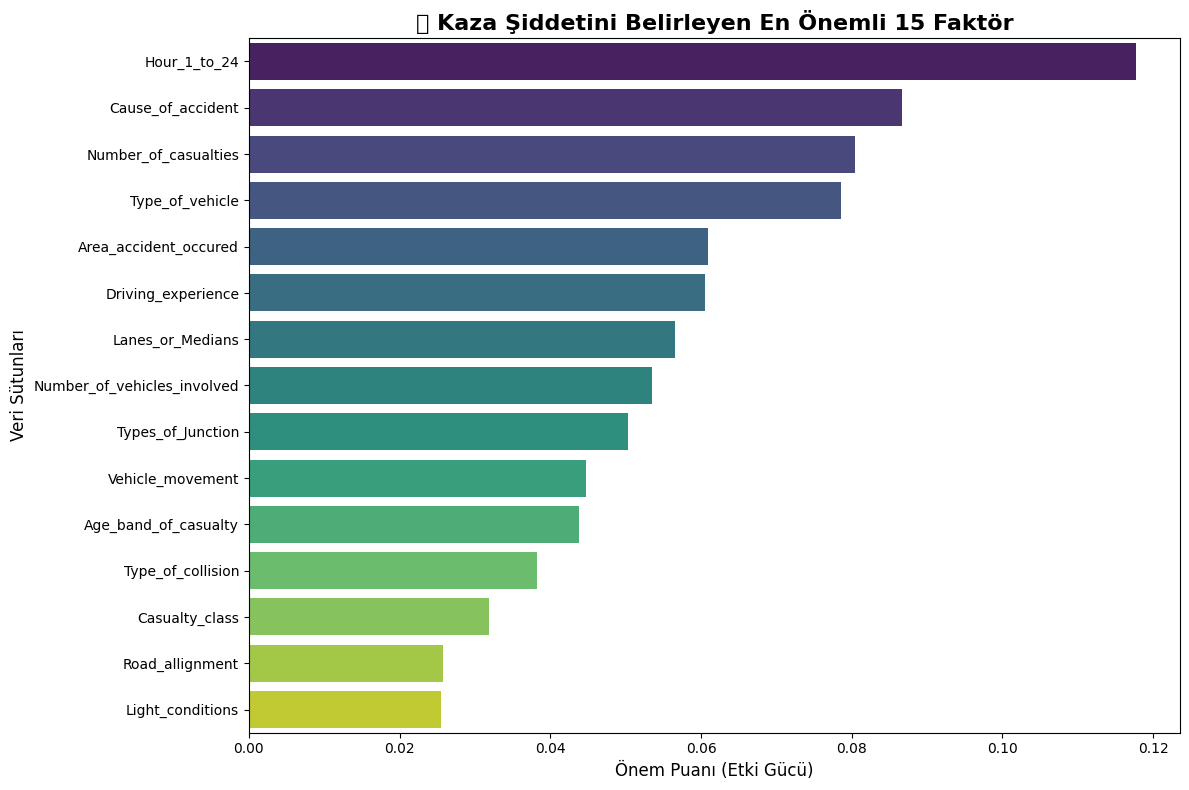

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 Modelin Karar Mekanizması Çözümleniyor...\n")

# 1. Modelin içinden her bir özelliğin (sütunun) önem puanını çekiyoruz
onem_puanlari = rf_model.feature_importances_

# 2. Bu puanları sütun isimlerimizle eşleştirip güzel bir tablo (DataFrame) yapıyoruz
ozellik_onemi_df = pd.DataFrame({
    'Özellik': X.columns,
    'Önem_Puanı': onem_puanlari
})

# 3. Puanları en yüksekten en düşüğe doğru sıralıyoruz
ozellik_onemi_df = ozellik_onemi_df.sort_values(by='Önem_Puanı', ascending=False)

# 4. Şov Vakti: Muazzam bir grafik çizdiriyoruz
plt.figure(figsize=(12, 8))
# İlk 15 en önemli özelliği çizdirelim ki grafik çok kalabalık olmasın
sns.barplot(x='Önem_Puanı', y='Özellik', data=ozellik_onemi_df.head(15), palette='viridis')

plt.title('🚦 Kaza Şiddetini Belirleyen En Önemli 15 Faktör', fontsize=16, fontweight='bold')
plt.xlabel('Önem Puanı (Etki Gücü)', fontsize=12)
plt.ylabel('Veri Sütunları', fontsize=12)
plt.tight_layout()
plt.show()